# Bias Analysis - Study2a

## Loading Libraries & Data

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import matplotlib.colors as mcolors
import requests
from pathlib import Path
import json
import re
import yfinance as yf
import math
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
import itertools
import string

In [2]:
ageRisk = pd.read_csv('./data/ageRisk_long.csv', index_col=0)

In [3]:
ageRisk.shape

(977, 12)

## Resolving ETFs 

In [4]:
def get_position_weight(portfolio_df):
    position_weight = portfolio_df / portfolio_df.sum()
    return position_weight

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration', 'ticker_symbol', 'amount_to_invest', 'weight', 'sector', 'asset_type', 'country']
ageRisk['weight'] = ageRisk.groupby(['ai', 'age', 'risk-taking', 'cond', 'iteration'])['amount_to_invest'].transform(get_position_weight)
ageRisk = ageRisk[ageRisk_select_cols]

ageRisk_unique_etfs = ageRisk[ageRisk["asset_type"] == "ETF"]["ticker_symbol"].unique()
etfs = ageRisk_unique_etfs

ageRisk_unique_funds = ageRisk[ageRisk["asset_type"] == "MUTUALFUND"]["ticker_symbol"].unique()
funds = ageRisk_unique_funds

In [5]:
def prepare_refinitiv_dataset(df, columns):
    df = df.iloc[1:].reset_index()
    df.columns = columns
    df['economic_sector'] = df['economic_sector'].replace('Unable to resolve all requested identifiers.', np.nan)
    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['economic_sector'].str.startswith('Unable to')
    df.loc[condition & ~df['economic_sector'].isna(), 'country'] = np.nan
    df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
    df['weight'] = df['weight'].fillna(100.0)
    df['weight'] = df['weight'] / 100
    df['fund'] = df['fund'].str.split('.').str[0]
    return df

study1_etf_data = pd.read_csv('../study1/etf_holdings/refinitiv/etfs_refinitiv.csv', index_col=0, low_memory=False)
study1_fund_data = pd.read_csv('../study1/mutualFund_holdings/refinitiv/mutualFunds_refinitiv.csv', index_col=0, low_memory=False)

cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'type', 'economic_sector']
study1_etf_data = prepare_refinitiv_dataset(study1_etf_data, cols_refinitiv)
study1_etfs = study1_etf_data['fund'].unique()

study1_fund_data = study1_fund_data.iloc[:,:-2]
study1_fund_data = prepare_refinitiv_dataset(study1_fund_data, cols_refinitiv)
study1_funds = study1_fund_data['fund'].unique()

study2b_fund_data = pd.read_csv('../study2b/data/refinitiv/funds_refinitiv_study2b.csv', index_col=0, low_memory=False)
study2b_fund_data = prepare_refinitiv_dataset(study2b_fund_data, cols_refinitiv)
study2b_funds = study2b_fund_data['fund'].unique()

study2a_addition_data = pd.read_csv('../study1/etf_holdings/refinitiv/additions_refinitiv.csv', index_col=0)
study2a_addition_data = prepare_refinitiv_dataset(study2a_addition_data, cols_refinitiv)
study2a_additions = study2a_addition_data['fund'].unique()

prev_etfs = np.union1d(np.union1d(study1_etfs, study2b_funds), study2a_additions ) 
prev_funds = np.union1d(np.union1d(study1_funds, study2b_funds), study2a_additions)

new_etfs = [item for item in etfs if item not in prev_etfs]
new_funds = [item for item in funds if item not in prev_funds]

In [6]:
new_etfs

['XBI',
 'LIT',
 'TLH',
 'SCHK',
 'GBTC',
 'REET',
 'MCHI',
 'INDA',
 'IWO',
 'ARKF',
 'IPO',
 'CIBR',
 'USMV',
 'SCHD',
 'IYR',
 'PBW',
 'USO']

In [7]:
resStr_etf = ""
os = ['MCHI', 'IXUS', 'ACWX', 'DVY', 'CIBR']
ks = ['SCHK', 'REET', 'INDA', 'ARKF', 'SCHD', 'USMV']
for etf in new_etfs:
    if etf in os:
        resStr_etf += f'{etf}.O;'
    elif etf in ks:
        resStr_etf += f'{etf}.K;'
    else:
        resStr_etf += f'{etf};'
resStr_etf

'XBI;LIT;TLH;SCHK.K;GBTC;REET.K;MCHI.O;INDA.K;IWO;ARKF.K;IPO;CIBR.O;USMV.K;SCHD.K;IYR;PBW;USO;'

In [8]:
new_funds

[nan, 'VTISX', 'PRBLX']

In [9]:
resStr_mutualFunds = "";
delisted = ['VTWSX', 'VDAIX']
for fund in new_funds:
    if fund in delisted:
        resStr_mutualFunds += f'{fund}.O^K19;'
    else:
        resStr_mutualFunds += f'{fund}.O;'
resStr_mutualFunds

'nan.O;VTISX.O;PRBLX.O;'

In [10]:
resStr_funds = resStr_etf + resStr_mutualFunds
resStr_funds

'XBI;LIT;TLH;SCHK.K;GBTC;REET.K;MCHI.O;INDA.K;IWO;ARKF.K;IPO;CIBR.O;USMV.K;SCHD.K;IYR;PBW;USO;nan.O;VTISX.O;PRBLX.O;'

In [11]:
# BSCM ended on 15.12.2022, GLD, SLV, DbC

## Loading Data from Refinitiv & Resolving Dataset

In [12]:
cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector']

study2a_fund_data = pd.read_csv('./data/refinitiv/funds_refinitiv_study2a.csv', index_col=0, low_memory=False)
study2a_fund_data = prepare_refinitiv_dataset(study2a_fund_data, cols_refinitiv)
study2a_fund_data = study2a_fund_data[study2a_fund_data['fund'].isin(new_funds)]

study2a_etf_data = pd.read_csv('./data/refinitiv/etfs_refinitiv_study2a.csv', index_col=0)
study2a_etf_data = prepare_refinitiv_dataset(study2a_etf_data, cols_refinitiv)
study2a_etf_data = study2a_etf_data[study2a_etf_data['fund'].isin(new_etfs)]

etf_data = pd.concat([
    study1_etf_data, 
    study2a_fund_data,
    study2a_addition_data,
    study2a_etf_data], ignore_index=True)

fund_data = pd.concat([
    study1_etf_data, 
    study1_fund_data, 
    study2a_addition_data, 
    study2a_fund_data,
    study2a_etf_data,
    study2b_fund_data], ignore_index=True)

In [13]:
def create_ticker(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['symbol']
    else:
        return row['ticker_symbol']

def create_ticker_l2(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['ticker'] if pd.isnull(row['equity_l2']) else row['symbol_l2']
    else:
        return row['ticker']
    
def harmonize_sectors(sector):
    if sector == 'Consumer Cyclicals':
        return 'Consumer Cyclical'
    elif sector == 'Financial Services':
        return 'Financials'
    elif sector == 'Consumer Defensive':
        return 'Consumer Non-Cyclicals'
    else:
        return sector
    
def resolve_layer2(df, select_cols):
    df = df.merge(etf_data, left_on='ticker', right_on='fund', how='left', suffixes=('_l1','_l2'))
    df['weight_l2'].fillna(1, inplace=True)
    df['weight'] = df['weight_l1'] * df['weight_l2']
    df['sector'] = df['sector'].fillna(df['economic_sector_l2'])
    df['country'] = df.apply(
        lambda row: row['country_l2'] if pd.isnull(row['country_l1']) else row['country_l1'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker_l2(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount'] * row['weight_l2'], axis=1)

    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['sector'].str.startswith('Unable to')
    df.loc[condition & ~df['sector'].isna(), 'sector'] = np.nan

    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    df['country'] = df['country'].fillna('UNKNOWN')
    df['ticker'] = df['ticker'].fillna('UNKNOWN')
    #df = df[select_cols]
    return df

def prepare_data(df, select_cols):
    df = df.merge(fund_data, left_on='ticker_symbol', right_on='fund', how='left')
    df['weight_y'].fillna(1, inplace=True)
    df['weight'] = df['weight_x'] * df['weight_y']
    df['sector'] = df['sector'].fillna(df['economic_sector'])
    df['sector'] = df.apply(
        lambda row: 'Crypto' if row['asset_type'] == 'CRYPTOCURRENCY' else row['sector'],
        axis=1
    )
    df['country_x'] = df['country_x'].str.upper()
    df['country'] = df.apply(
        lambda row: row['country_y'] if pd.isnull(row['country_x']) else row['country_x'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount_to_invest'] * row['weight_y'], axis=1)
    df['sector'] = df['sector'].apply(harmonize_sectors)
    #return df
    return resolve_layer2(df, select_cols)

def prepare_benchmark(df):
    df = df.rename(columns={'economic_sector': 'sector'})
    df['amount'] = df['weight'].apply(lambda x: x * 10000)
    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['country'] = df['country'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    return df

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration', 'asset_type', 'ticker', 'weight', 'country', 'sector', 'amount']
ageRisk_resolved = prepare_data(ageRisk, ageRisk_select_cols)

benchmark_cols_refinitiv = ['fund', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector', 'business_sector', 'industry_group']
benchmark = pd.read_csv('../study1/benchmark/refinitiv/benchmarks_refinitiv.csv', index_col=0)
benchmark_prepared = prepare_benchmark(prepare_refinitiv_dataset(benchmark, benchmark_cols_refinitiv))


In [14]:
ageRisk_resolved.head()

,ai,age,risk-taking,cond,iteration,ticker_symbol,amount_to_invest,weight_x,sector,asset_type,...,code_l2,equity_l2,symbol_l2,#shares_l2,weight_l2,country_l2,type_l2,economic_sector_l2,weight,country
0,ChatGPT,15,averse,control,0,SPY,4000.0,0.4,Technology,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.030279,UNITED STATES
1,ChatGPT,15,averse,control,0,SPY,4000.0,0.4,Technology,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.026038,UNITED STATES
2,ChatGPT,15,averse,control,0,SPY,4000.0,0.4,Consumer Cyclical,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.012440,UNITED STATES
3,ChatGPT,15,averse,control,0,SPY,4000.0,0.4,Technology,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.012048,UNITED STATES
4,ChatGPT,15,averse,control,0,SPY,4000.0,0.4,Technology,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.008223,UNITED STATES


In [15]:
benchmark_ftse = benchmark_prepared[benchmark_prepared['fund'] == 'VFAWF']
benchmark_msci = benchmark_prepared[benchmark_prepared['fund'] == 'IUSQ']
benchmark_vt = pd.read_csv('../study1/benchmark/refinitiv/benchmark_vt.csv', index_col=0)

In [16]:
def prepare_dataframe(df, col_name, sep_col = None, sep_col_values = None):
    ages = [15, 30, 50]
    risk_taking = ['averse', 'neutral', 'seeking']
    cond = df['cond'].unique()
    iterations = list(range(10))  # 0 to 9
    
    if sep_col:
        combinations = list(itertools.product(ages, risk_taking, cond, iterations, sep_col_values))

        missing_rows = pd.DataFrame(combinations, columns=['age', 'risk-taking', 'cond', 'iteration', sep_col])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['age', 'risk-taking', 'iteration', 'cond', sep_col], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df
    else:
        combinations = list(itertools.product(ages, risk_taking, cond, iterations))
        
        missing_rows = pd.DataFrame(combinations, columns=['age', 'risk-taking', 'cond', 'iteration'])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['age', 'risk-taking', 'cond', 'iteration'], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df

## Graphs

In [17]:
mpl.rcParams['font.size'] = 14  # Change the size to your preference
mpl.rcParams['font.sans-serif'] = 'Arial'

In [18]:
def fill_options(filtered_df, res_df, elem, group_cols):
    elems = filtered_df[elem].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame([row + [el] for row in group_cols_df.values.tolist() for el in elems], columns=group_cols+[elem])
    merged = pd.merge(all_combinations, res_df, on=group_cols+[elem], how='left')
    merged.fillna(0, inplace=True)
    return merged

def calculate_weight(group, elem):
    summed = group.groupby(elem)['amount'].sum().reset_index()
    total_amount = summed['amount'].sum()
    summed['weight'] = summed['amount'] / total_amount
    return summed

def create_benchmark_dummy(df, benchmark_label):
    benchmark_ai = f'{benchmark_label}'
    df['cond'] = benchmark_ai
    df['ai'] = benchmark_ai
    df['age'] = 1
    df['risk-taking'] = 'low'
    df['iteration'] = 0
    return df

def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df = df.copy()
        df.loc[:, 'label'] = df.loc[:, group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)
    
def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        print(f'group: {group_name} got t: {t_statistic} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 4)}')

def calc_stats(raw, column, benchmark, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors

def print_stats(raw, column, benchmark, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors
    

def show_benchmark_violinplot(raw, benchmark, benchmark_label, column, column_label, group1, filename):
    means, _, _,_ = print_stats(raw, column, benchmark, group1)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=raw, x=group1, y=column, split=False, inner=None, linewidth=1, ax=ax, edgecolor='black', fill=None, zorder=2)

    # Add boxplots
    sns.boxplot(data=raw, x=group1, y=column, hue=group1, width=0.2, palette="Set3", ax=ax, 
                boxprops=dict(edgecolor='black', facecolor=(1, 1, 1, 0)), 
                medianprops=dict(linewidth=2, color='black'), 
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'), fliersize=0, legend=False, zorder=4)

    for i, group in enumerate(raw[group1].unique()):
        group_data = raw[raw[group1] == group][column]
        jitter = np.random.normal(i, 0.04, size=len(group_data))
        ax.scatter(jitter, group_data, s=100, alpha=0.4, zorder=3)  # Set zorder to ensure dots are on top

        # Calculate the mean and add it to the boxplot
        mean = group_data.mean()
        ax.scatter(i, mean, color='black', s=50, label='mean', zorder=5)

    ax.axhline(y=benchmark, color='black', linestyle='--', label=benchmark_label, zorder=4)
    ax.set_ylabel(column_label)
    ax.set_xticks(range(len(means.index)))
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(f'./figures/{filename}.png')
    plt.show()

def print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label):
    # Create a stacked barplot with error bars
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 5), zorder=2, color=['darkgrey'])
    ax.axhline(y=benchmark, color='red', linestyle='--', label=benchmark_label)
    ax.set_ylabel(column_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.annotate(benchmark_label, xy=(0, benchmark), xytext=(0, 1),
            color='red', fontsize=10, ha='left', va='bottom', textcoords='offset points')

    # Show the plot
    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    plt.show()
    

def show_benchmark_errplot(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

def show_benchmark_errplot_complete(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = print_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

def rescale(df, col):
    res = df.copy()
    res[col] = res[col] * 100
    return res

group_cols = ['cond', 'age', 'risk-taking', 'iteration']
vt_dummy = create_benchmark_dummy(benchmark_vt, 'VT')

ageRisk_resolved['cond'] = ageRisk_resolved['cond'].replace({'control': 'Control prompt','engineered': 'Debiased prompt'})
ageRisk['cond'] = ageRisk['cond'].replace({'control': 'Control prompt','engineered': 'Debiased prompt'})


## Geographic cluster risk

In [19]:
def prepare_geographic_data(df, is_benchmark = False):
    df = df.copy()
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['country'] != 'UNKNOWN'] 
    df['country'] = df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(df.shape)
    return df

benchmark_filtered = prepare_geographic_data(vt_dummy, True)
geo_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
geo_benchmark_us = geo_benchmark[geo_benchmark['country']=='US'].iloc[0]['weight']
geo_benchmark_us = geo_benchmark_us * 100

filtered_df = prepare_geographic_data(ageRisk_resolved)
geo = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
#geo = prepare_dataframe(geo, 'weight', 'country', geo['country'].unique()) #leave data point out due to wrong labeling
geo_us = geo[geo['country']=='US']
geo_us = rescale(geo_us, 'weight')

(9485, 15)
(1304007, 35)


                sum_sq     df         F    PR(>F)
label       931.505213    1.0  8.638407  0.003728
Residual  19194.271388  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt  -4.5497 0.0037 -7.6045 -1.495   True
--------------------------------------------------------------------
group: ('Control prompt',) got t: 38.39152231342702 p_value: 0.0 dfs: 89 benchmark: 58.9625
group: ('Debiased prompt',) got t: 25.50658559821182 p_value: 0.0 dfs: 89 benchmark: 58.9625
means:
cond
Control prompt     94.9394
Debiased prompt    90.3897
Name: weight, dtype: float64
stds:
cond
Control prompt      8.8902
Debiased prompt    11.6889
Name: weight, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: weight, dtype: int64


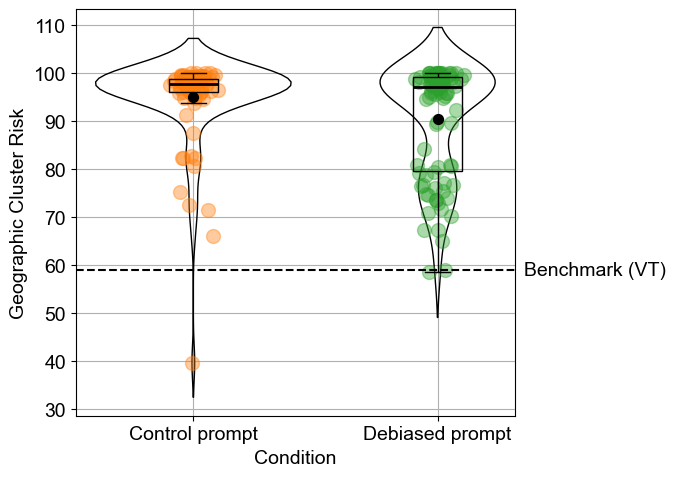

In [20]:
show_benchmark_violinplot(
    geo_us, 
    geo_benchmark_us, 
    'Benchmark (VT)', 
    'weight',
    'Geographic Cluster Risk', #US assets portfolio share [%]
    'cond',
    'study2a_geoRisk'
)

                sum_sq     df         F    PR(>F)
label       931.505213    1.0  8.638407  0.003728
Residual  19194.271388  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt  -4.5497 0.0037 -7.6045 -1.495   True
--------------------------------------------------------------------
group: ('Control prompt',) got t: 38.39152231342702 p_value: 0.0 dfs: 89 benchmark: 58.9625
group: ('Debiased prompt',) got t: 25.50658559821182 p_value: 0.0 dfs: 89 benchmark: 58.9625


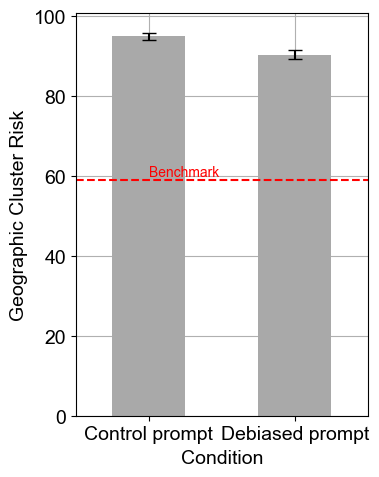

In [21]:
show_benchmark_errplot(geo_us, 
    geo_benchmark_us, 
    'Benchmark', 
    'weight',
    'Geographic Cluster Risk', #US assets portfolio share [%]
    'cond')

## Sector cluster risk

In [22]:
def prepare_sector_data(df, is_benchmark = False):
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['sector'] != 'UNKNOWN'] 
    print(df.shape)
    return df

def calculate_concentration(result, group):
    result['weight_squared'] = result['weight'] ** 2
    result_sum = result.groupby(group)['weight'].sum().reset_index()
    result_sum = result_sum['weight'] ** 2
    result_grouped = result.groupby(group)['weight_squared'].sum().reset_index()
    result_grouped['concentration'] = result_grouped['weight_squared'] / result_sum
    return result_grouped

benchmark_filtered = prepare_sector_data(vt_dummy, True)
sec_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_benchmark = calculate_concentration(sec_benchmark, group_cols)
sec_benchmark = sec_benchmark.iloc[0]['concentration']

filtered_df = prepare_sector_data(ageRisk_resolved)
sec = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
#sec = prepare_dataframe(sec, 'weight', 'sector', sec['sector'].unique()) #left out as before
sec = calculate_concentration(sec, group_cols)

(9621, 15)
(1248146, 35)


            sum_sq     df         F    PR(>F)
label     0.083447    1.0  4.432377  0.036666
Residual  3.351156  178.0       NaN       NaN
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------
Control prompt Debiased prompt  -0.0431 0.0367 -0.0834 -0.0027   True
---------------------------------------------------------------------
group: ('Control prompt',) got t: 11.914717655086994 p_value: 0.0 dfs: 89 benchmark: 0.1528
group: ('Debiased prompt',) got t: 8.358374162353295 p_value: 0.0 dfs: 89 benchmark: 0.1528
means:
cond
Control prompt     0.3201
Debiased prompt    0.2770
Name: concentration, dtype: float64
stds:
cond
Control prompt     0.1332
Debiased prompt    0.1411
Name: concentration, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: concentration, dtype: int64


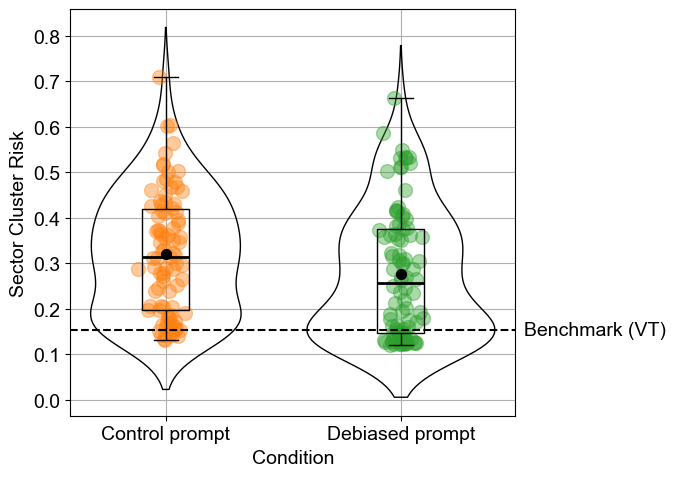

In [23]:
show_benchmark_violinplot(
    sec, 
    sec_benchmark, 
    'Benchmark (VT)', 
    'concentration',
    'Sector Cluster Risk', #Sector Concentration 
    'cond',
    'study2a_sectorRisk'
)

            sum_sq     df         F    PR(>F)
label     0.083447    1.0  4.432377  0.036666
Residual  3.351156  178.0       NaN       NaN
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------
Control prompt Debiased prompt  -0.0431 0.0367 -0.0834 -0.0027   True
---------------------------------------------------------------------
group: ('Control prompt',) got t: 11.914717655086994 p_value: 0.0 dfs: 89 benchmark: 0.1528
group: ('Debiased prompt',) got t: 8.358374162353295 p_value: 0.0 dfs: 89 benchmark: 0.1528


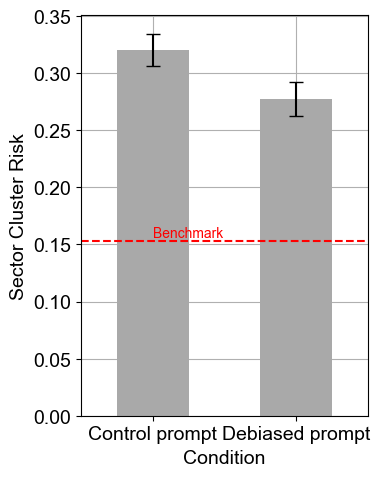

In [24]:
show_benchmark_errplot(
    sec, 
    sec_benchmark, 
    'Benchmark', 
    'concentration',
    'Sector Cluster Risk', #Sector Concentration 
    'cond')

## Concentration Map

In [25]:
def prepare_overview_data(df, isBenchmark = False):
    filtered_df = df.copy()
    if not isBenchmark:
        filtered_df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    filtered_df = filtered_df[filtered_df['country'] != 'UNKNOWN'] 
    filtered_df = filtered_df[filtered_df['sector'] != 'UNKNOWN']
    filtered_df['country'] = filtered_df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(filtered_df.shape)
    return filtered_df

def calc_overview(raw, column, column_label, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

def show_matched_ttest(raw, column, benchmark):
    for group_name, group_data in raw.groupby(column):
        group_values = group_data['weight']
        benchmark_val = 0
        if len(benchmark[benchmark[column] == group_name]) > 0:
            benchmark_val = benchmark[benchmark[column] == group_name].iloc[0]['weight']
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark_val)
        print(f'group: {group_name} with mean {round(group_values.mean(),4)} and std {round(group_values.std(),4)} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark_val, 4)}')

filtered_df = prepare_overview_data(ageRisk_resolved)

sec_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_ov = fill_options(filtered_df, sec_ov, 'sector', group_cols)
calc_overview(sec_ov, 'weight','weight','sector')

bench_sec_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
show_matched_ttest(sec_ov, 'sector', bench_sec_ov)

geo_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
gec_ov = fill_options(filtered_df, geo_ov, 'country', group_cols)
calc_overview(geo_ov, 'weight','weight','country')

bench_geo_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
show_matched_ttest(geo_ov, 'country', bench_geo_ov)


(1232105, 35)
             sum_sq      df           F  PR(>F)
label     21.514462    13.0  213.676974     0.0
Residual  19.409327  2506.0         NaN     NaN
                                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                                     
                  group1                                     group2                   meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------------------
           Academic & Educational Services                            Basic Materials   0.0116 0.9938 -0.0196  0.0427  False
           Academic & Educational Services                     Communication Services   0.0271 0.1686  -0.004  0.0583  False
           Academic & Educational Services                          Consumer Cyclical   0.2384    0.0  0.2073  0.2696   True
           Academic & Educational Services                     Consumer Non-Cyclicals   0.04

(9485, 15)


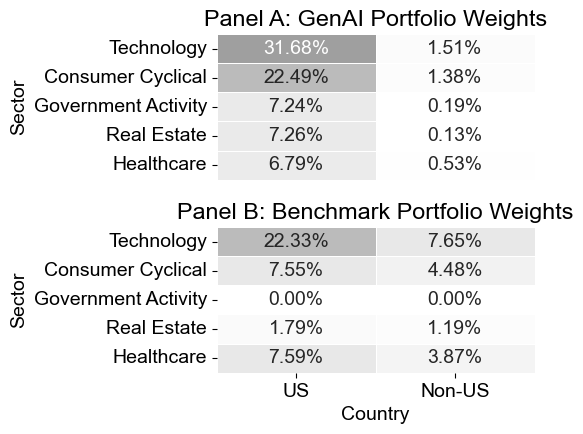

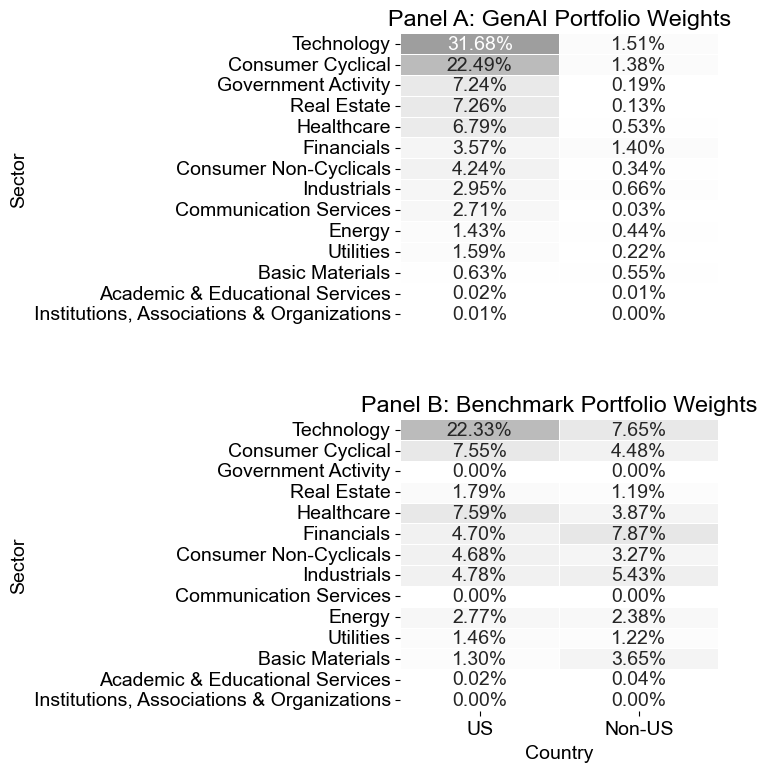

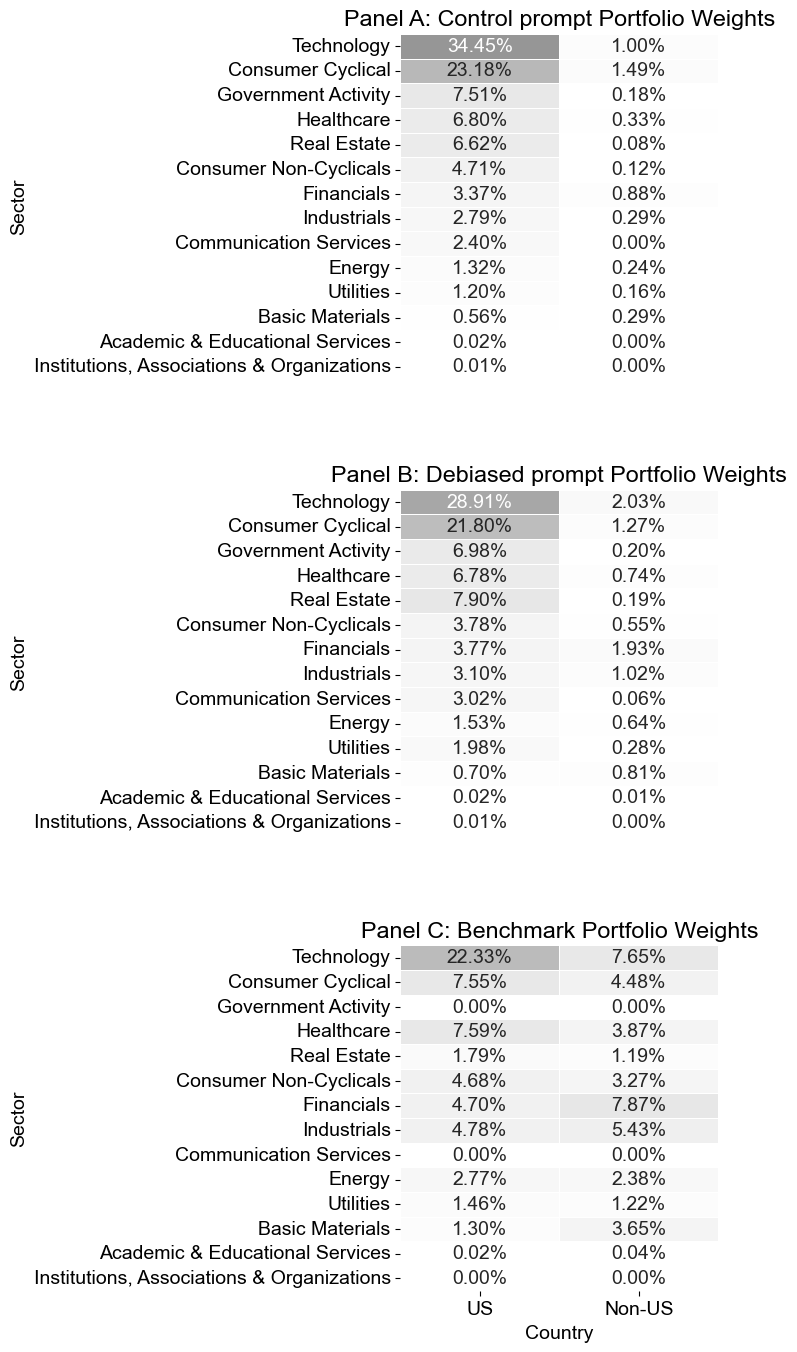

In [26]:
def fill_concentration(filtered_df, res, group_cols):
    sectors = filtered_df['sector'].unique()
    countries = filtered_df['country'].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame(
        [row + [sector, country] for row in group_cols_df.values.tolist() for sector, country in itertools.product(sectors, countries)], 
        columns=group_cols+['sector', 'country'])

    merged_df = pd.merge(all_combinations, res, on=group_cols+['sector', 'country'], how='left')
    merged_df.fillna(0, inplace=True)
    return merged_df

def custom_heatmap(data, color_map="gray_r", annot=True, fmt=".2%", ax=None, max_color=None, **kwargs):
    sns.heatmap(data, cmap=color_map, annot=annot, fmt=fmt, linewidths=.5, cbar=False, ax=ax, vmax=max_color, **kwargs)

import numpy as np

def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).nlargest(5).index
    else:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(index=row_order, fill_value=0)
        facet_pivot = facet_pivot.reindex(columns=facet_pivot.columns[::-1], fill_value=0)  # Reverse column order
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)        
        ax.set_yticks(np.arange(len(facet_pivot.index)) + 0.5)
        ax.set_yticklabels(facet_pivot.index, va='center')  # Set y-tick labels
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    g.set_axis_labels("Country", "Sector")
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'GenAI'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['cond'] 

combined = pd.concat([concentration_overview, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined, 'study2a_overview_concentration_map', True, 4, 4)
show_faceted_heatmap(combined, 'study2a_concentration_map', False, 4, 8)

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'study2a_concentration_map_details', False, 4, 14)

(9485, 15)


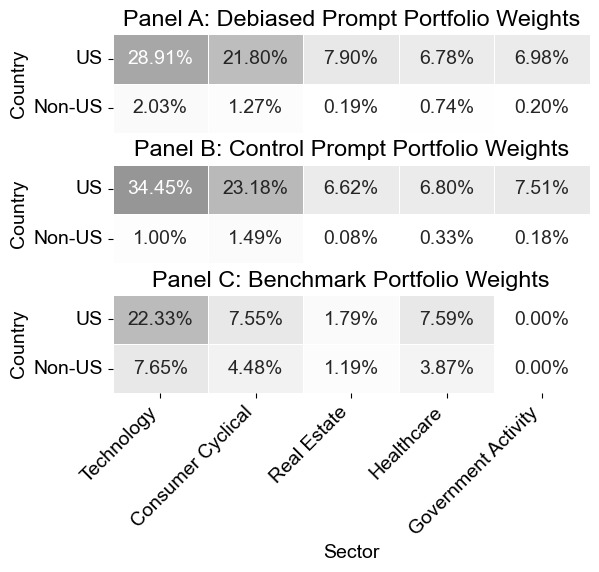

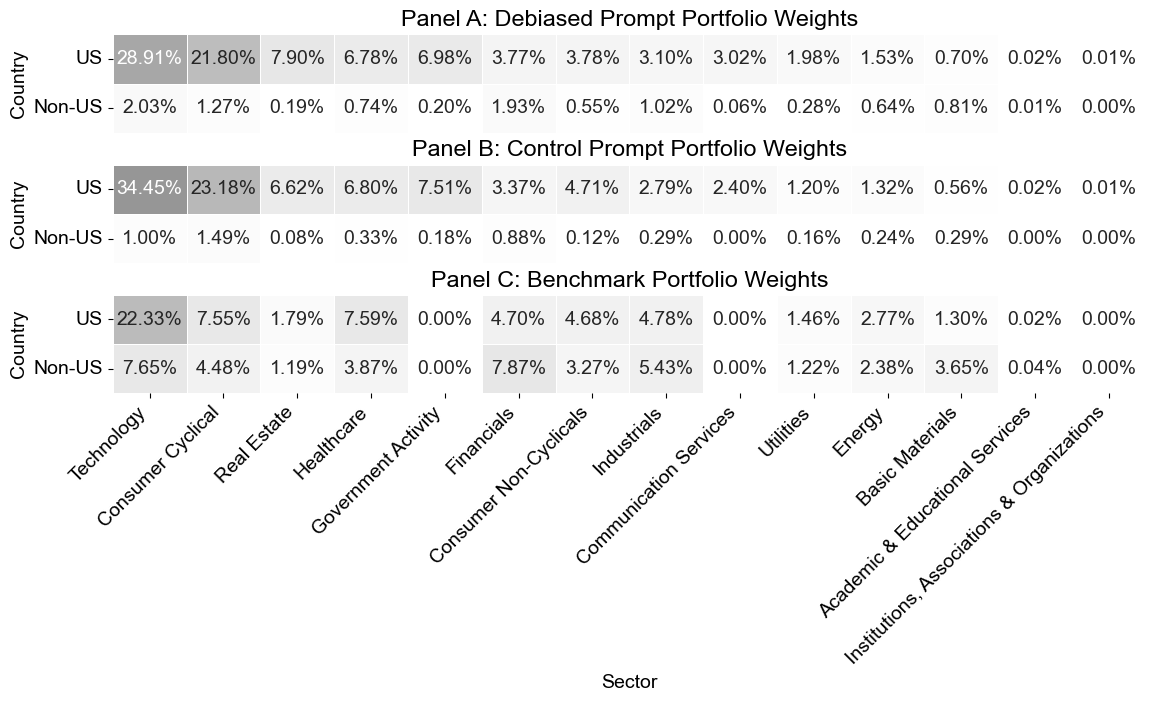

In [27]:
def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()
    combined_df = combined_df.sort_values(by='type', ascending=False)
    replacements = {'Control prompt': 'Control Prompt', 'Debiased prompt': 'Debiased Prompt'}
    combined_df['type'] = combined_df['type'].replace(replacements)

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).nlargest(5).index
    else:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(columns=column_order, fill_value=0)
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    g.set_axis_labels("Sector", "Country")
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'GenAI'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['cond'] 

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'study2a_overview_concentration_map_horizontal', True, 6, 4)
show_faceted_heatmap(combined_details, 'study2a_details_concentration_map_horizontal', False, 13, 4)

## Active investment allocation risk

In [28]:
ter_data_study1 = pd.read_csv('../study1/etf_holdings/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study1 = ter_data_study1.iloc[1:].reset_index()
ter_data_study1.columns = ['fund', 'fund_type', 'ter', 'management_approach']
ter_data_study1 = ter_data_study1[~ter_data_study1['management_approach'].isna()]

ter_data_study2b = pd.read_csv('../study2b/data/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study2b = ter_data_study2b.iloc[1:].reset_index()
ter_data_study2b.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data_study2a = pd.read_csv('./data/refinitiv/ter_study2a.csv', index_col=0)
ter_data_study2a = ter_data_study2a.iloc[1:].reset_index()
ter_data_study2a.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data = pd.concat([ter_data_study1, ter_data_study2b, ter_data_study2a], ignore_index=True)
ter_data['fund'] = ter_data['fund'].str.split('.').str[0]
condition = ter_data['ter'].str.startswith('Unable to')
ter_data.loc[condition & ~ter_data['ter'].isna(), 'ter'] = np.nan

In [29]:
def set_management_approach(row):
    if row['asset_type'] in ['EQUITY', 
                               'CRYPTOCURRENCY', 
                               'BOND', 
                               'MONEYMARKET', 
                               'SEEDINVEST', 
                               'REALESTATE', 
                               'ROBO', 
                               'VENTURECAPITAL',
                               'PRIVATEEQUITY']:
        return 'Active'
    else:
        ticker = row['ticker_symbol']
        if ticker in ter_data['fund'].unique():
            approach = ter_data[ter_data['fund'] == ticker].iloc[0]['management_approach']
            return approach
        else:
            return 'UNKNOWN'

def calculate_approach_weight(group):
    summed = group.groupby('management_approach')['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['management_weight'] = summed['amount_to_invest'] / total_amount
    return summed

def get_management_data(df, groups):
    df = df[df['management_approach'] != 'UNKNOWN']
    management_data = df.groupby(groups).apply(calculate_approach_weight).reset_index()
    return management_data      

investment_ageRisk = ageRisk[~ageRisk['asset_type'].isin(['SAVING', 'DEPOSIT', 'IRA', 'ANNUITY'])]
investment_ageRisk = investment_ageRisk.copy()
investment_ageRisk['management_approach'] = investment_ageRisk.apply(set_management_approach, axis=1)
management_data = get_management_data(investment_ageRisk, group_cols)
management_data = prepare_dataframe(management_data, 'management_weight', 'management_approach', ['Active', 'Passive'])
management_data = management_data[management_data['management_approach'] == 'Active']
management_data['management_weight'] = management_data['management_weight'] *100

                 sum_sq     df         F    PR(>F)
label       5289.279768    1.0  4.178703  0.042408
Residual  225307.162177  178.0       NaN       NaN
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
    group1          group2     meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------
Control prompt Debiased prompt -10.8416 0.0424 -21.3076 -0.3755   True
----------------------------------------------------------------------
group: ('Control prompt',) got t: 18.237049859522692 p_value: 0.0 dfs: 89 benchmark: 0
group: ('Debiased prompt',) got t: 11.660771582648524 p_value: 0.0 dfs: 89 benchmark: 0
means:
cond
Control prompt     59.5663
Debiased prompt    48.7247
Name: management_weight, dtype: float64
stds:
cond
Control prompt     30.9861
Debiased prompt    39.6409
Name: management_weight, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: management_weight, dtype: int64


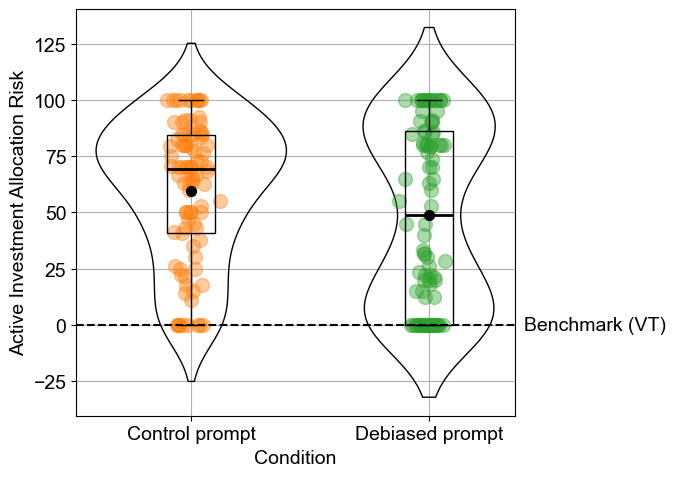

In [30]:
show_benchmark_violinplot(
    management_data, 
    0, 
    'Benchmark (VT)', 
    'management_weight',
    'Active Investment Allocation Risk', #Active management portfolio weight [%]
    'cond',
    'study2a_activeRisk'
)

                 sum_sq     df         F    PR(>F)
label       5289.279768    1.0  4.178703  0.042408
Residual  225307.162177  178.0       NaN       NaN
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
    group1          group2     meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------
Control prompt Debiased prompt -10.8416 0.0424 -21.3076 -0.3755   True
----------------------------------------------------------------------
group: ('Control prompt',) got t: 18.237049859522692 p_value: 0.0 dfs: 89 benchmark: 0
group: ('Debiased prompt',) got t: 11.660771582648524 p_value: 0.0 dfs: 89 benchmark: 0


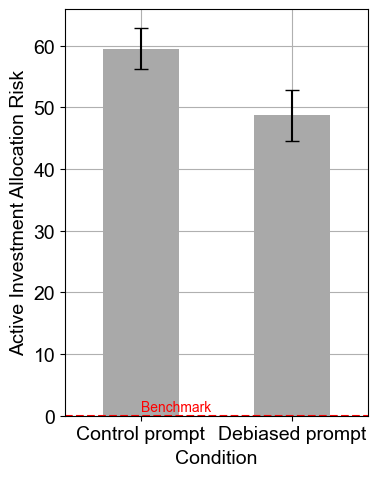

In [31]:
show_benchmark_errplot(
    management_data, 
    0, 
    'Benchmark', 
    'management_weight',
    'Active Investment Allocation Risk', #Active management portfolio weight [%]
    'cond')

## Total Expense Risk

In [32]:
fund_identifiers = ter_data['fund'].unique()
def assign_ter(row):
    ticker = row['ticker_symbol']
    if ticker in fund_identifiers:
        return ter_data[ter_data['fund'] == ticker].iloc[0]['ter']
    else: 
        return np.nan

def calculate_fund_weight(group, elem):
    summed = group.groupby(elem)['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['weight'] = summed['amount_to_invest'] / total_amount
    return summed

ter_benchmark = float(ter_data[ter_data['fund'] == 'VT'].iloc[0]['ter'])
ter_benchmark = ter_benchmark

filtered_df = ageRisk[ageRisk['asset_type'].isin(['ETF', 'MUTUALFUND'])]
ter_df = filtered_df.copy()
ter_df = ter_df.groupby(group_cols).apply(calculate_fund_weight, elem='ticker_symbol').reset_index()
ter_df['ter'] = ter_df.apply(assign_ter, axis=1)
ter_df['ter'] = ter_df['ter'].astype(float)
ter_df['ter_weight'] = ter_df['ter'] * ter_df['weight']
grouped_ter = ter_df.groupby(group_cols)['ter_weight'].sum().reset_index()

            sum_sq     df         F    PR(>F)
label     0.009024    1.0  0.213594  0.644589
Residual  6.802184  161.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt  -0.0149 0.6446 -0.0786 0.0488  False
--------------------------------------------------------------------
group: ('Control prompt',) got t: 5.3362622067533705 p_value: 0.0 dfs: 85 benchmark: 0.07
group: ('Debiased prompt',) got t: 4.63042631077675 p_value: 0.0 dfs: 76 benchmark: 0.07
means:
cond
Control prompt     0.1908
Debiased prompt    0.1759
Name: ter_weight, dtype: float64
stds:
cond
Control prompt     0.2099
Debiased prompt    0.2006
Name: ter_weight, dtype: float64
cond
Control prompt     86
Debiased prompt    77
Name: ter_weight, dtype: int64


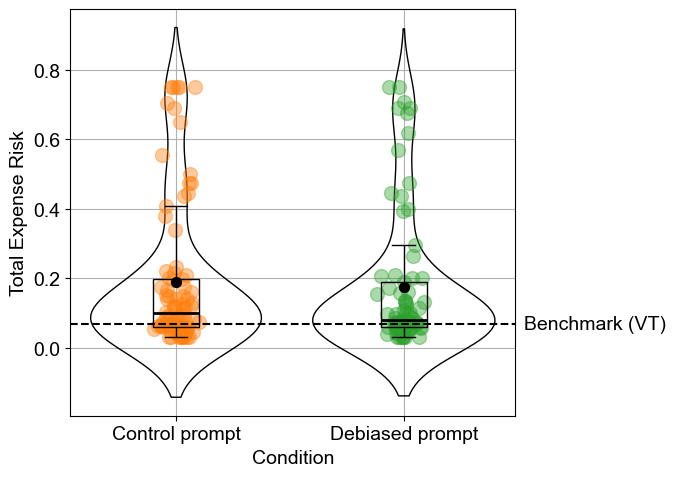

In [33]:
show_benchmark_violinplot(
    grouped_ter, 
    ter_benchmark, 
    'Benchmark (VT)', 
    'ter_weight',
    'Total Expense Risk', #TER % 
    'cond',
    'study2a_terRisk'
)

In [34]:
# Control for different N (portfolios being excluded due to no investment in ETFs or mutual funds
ter_control = grouped_ter[grouped_ter['cond'] == 'Control prompt']['ter_weight']
ter_debiased = grouped_ter[grouped_ter['cond'] == 'Debiased prompt']['ter_weight']

stat, p = stats.mannwhitneyu(ter_control, ter_debiased)
print(f'control-debiased: {stat}, {p}')

# Perform one-sample Wilcoxon signed-rank test
stat_bench, p_bench = stats.wilcoxon(ter_control - ter_benchmark)
print(f'control-benchmark: {stat_bench}, {p_bench}')

stat_debiased_bench, p_debiased_bench = stats.wilcoxon(ter_debiased - ter_benchmark)
print(f'debiased-benchmark: {stat_debiased_bench}, {p_debiased_bench}')

# Perform Chi-Square test
count_control = [90-ter_control.size, ter_control.size]
count_debiased = [90-ter_debiased.size, ter_debiased.size]

chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_control, count_debiased])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')

control-debiased: 3502.5, 0.5254020565532507
control-benchmark: 742.0, 1.1741970996749983e-06
debiased-benchmark: 747.0, 0.00020943346797558377
chi-square: 4.1573439191627575, 0.04145436160354038, df:1


In [35]:
ter_control.shape
ter_debiased.shape

(77,)

            sum_sq     df         F    PR(>F)
label     0.009024    1.0  0.213594  0.644589
Residual  6.802184  161.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt  -0.0149 0.6446 -0.0786 0.0488  False
--------------------------------------------------------------------
group: ('Control prompt',) got t: 5.3362622067533705 p_value: 0.0 dfs: 85 benchmark: 0.07
group: ('Debiased prompt',) got t: 4.63042631077675 p_value: 0.0 dfs: 76 benchmark: 0.07


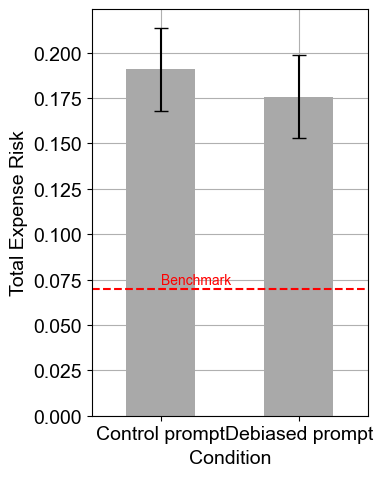

In [36]:
show_benchmark_errplot(
    grouped_ter, 
    ter_benchmark, 
    'Benchmark', 
    'ter_weight',
    'Total Expense Risk', #TER % 
    'cond')

## Trend chasing risk

In [37]:
vt_prepared = benchmark_vt
vt_prepared['symbol'] = vt_prepared['symbol'].str.split('.').str[0]
vt_prepared = vt_prepared['symbol'].unique()

volume_dict = {}
start_date = "2023-04-01"
end_date = "2023-06-30"

In [38]:
json_file_path = '../study1/benchmark/vt_benchmark_holdings_volume_202304_3m.json'

# Open and read the JSON file
with open(json_file_path, 'r') as json_file:
    # Load the JSON data into a dictionary
    volume_dict = json.load(json_file)
    
most_active_stocks = sorted(volume_dict.items(), key=lambda x: x[1], reverse=True)

# Most traded in the last 3 months by volume
most_traded = []
for i, (symbol, volume) in enumerate(most_active_stocks[:20], 1):
    most_traded.append(symbol)
    print(f"{i}. Symbol: {symbol}, Total Volume: {volume}")

1. Symbol: TSLA, Total Volume: 8627649000
2. Symbol: PLTR, Total Volume: 4490639300
3. Symbol: AMD, Total Volume: 4201460900
4. Symbol: AMZN, Total Volume: 3899624000
5. Symbol: F, Total Volume: 3708650700
6. Symbol: AAPL, Total Volume: 3541966300
7. Symbol: NIO, Total Volume: 3235177200
8. Symbol: SOFI, Total Volume: 3204363300
9. Symbol: BAC, Total Volume: 3044131000
10. Symbol: NKLA, Total Volume: 3010655200
11. Symbol: NVDA, Total Volume: 2965437300
12. Symbol: INTC, Total Volume: 2762170900
13. Symbol: CCL, Total Volume: 2498772900
14. Symbol: T, Total Volume: 2442695800
15. Symbol: GOOGL, Total Volume: 2081408400
16. Symbol: LCID, Total Volume: 1905241200
17. Symbol: AI, Total Volume: 1890107300
18. Symbol: NU, Total Volume: 1711794600
19. Symbol: MSFT, Total Volume: 1699893000
20. Symbol: PACW, Total Volume: 1662858500


In [39]:
def getTop(conds, cond, equities_cond, equities_grouped):
    top_data = {}
    
    for co in conds:
        top_equities_total = equities_cond[equities_cond['cond'] == co]['amount_to_invest']
        top_total = cond[cond['cond'] == co]['amount_to_invest']
        top_cond = equities_grouped[equities_grouped['cond'] == co]
        top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
        top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
        top_cond = top_cond.sort_values(by='amount_to_invest', ascending=False)
        top_data[co] = top_cond
        
    return top_data

def showTop(conds, top_data):
    top_dict = {}
    for co in conds:
        top = top_data[co]
        top_equities_sum = top['pct_of_equities'].sum()
        top_total_sum = top['pct_of_total'].sum()
        print(f'{co} top: % of equities: {top_equities_sum} and % of total {top_total_sum}')

        top3 = top.head(3)
        top3 = top3[top3['ticker_symbol'].isin(most_traded)]
        top3_equities_sum = top3['pct_of_equities'].sum()
        top3_total_sum = top3['pct_of_total'].sum()
        print(f'{co} top 3: % of equities: {top3_equities_sum} and % of total {top3_total_sum}')
        print(f'{top3}\n')
        top_dict[co] = top3['ticker_symbol'].tolist()
    return top_dict

conds = ageRisk['cond'].unique()
ageRisk_cond = ageRisk.groupby(['cond'])['amount_to_invest'].sum().reset_index()
ageRisk_equities = ageRisk[ageRisk['asset_type'] == 'EQUITY']
ageRisk_equities_cond = ageRisk_equities.groupby(['cond'])['amount_to_invest'].sum().reset_index()
ageRisk_equities_grouped = ageRisk_equities.groupby(['cond','ticker_symbol'])['amount_to_invest'].sum().reset_index()

top_data = getTop(conds, ageRisk_cond, ageRisk_equities_cond, ageRisk_equities_grouped)
top_dict = showTop(conds, top_data)

Control prompt top: % of equities: 1.0000000000000002 and % of total 0.4120148856990962
Control prompt top 3: % of equities: 0.6012903225806452 and % of total 0.2477405635300372
              cond ticker_symbol  amount_to_invest  pct_of_equities  \
0   Control prompt          AAPL           92000.0         0.237419   
24  Control prompt          TSLA           78000.0         0.201290   
3   Control prompt          AMZN           63000.0         0.162581   

    pct_of_total  
0       0.097820  
24      0.082935  
3       0.066986  

Debiased prompt top: % of equities: 0.9999999999999999 and % of total 0.3675074586384595
Debiased prompt top 3: % of equities: 0.6523985239852399 and % of total 0.23976132356929752
               cond ticker_symbol  amount_to_invest  pct_of_equities  \
26  Debiased prompt          AAPL           93500.0         0.276015   
60  Debiased prompt          TSLA           68000.0         0.200738   
30  Debiased prompt          AMZN           59500.0         0.1

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_25619/3554050832.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_25619/3554050832.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_25619/3554

In [40]:
top3_benchmark = vt_dummy.sort_values(by='weight', ascending=False).head(3) 
top3_benchmark #all included in top 20 most traded

,fund,code,equity,symbol,#shares,weight,country,type,sector,amount,cond,ai,age,risk-taking,iteration
93854,VT,LP40120747,APPLE INC ORD,AAPL,8132495.0,0.038911,UNITED STATES,Ordinary Shares,Technology,389.11,VT,VT,1,low,0
93855,VT,NaN,MICROSOFT CORP ORD,MSFT,4055679.0,0.033854,UNITED STATES,Ordinary Shares,Technology,338.54,VT,VT,1,low,0
93856,VT,NaN,AMAZON.COM INC ORD,AMZN,4909845.0,0.017257,UNITED STATES,Ordinary Shares,Consumer Cyclical,172.57,VT,VT,1,low,0


In [41]:
def calcTopMeans(df, top_dict):
    top_df = None

    for cond, top_assets in top_dict.items():
        filtered_df = df[(df['cond'] == cond) & (df['ticker_symbol'].isin(top_assets))]
        top_df = pd.concat([top_df, filtered_df])
    
    top_df = prepare_dataframe(top_df, 'weight')    
    result = top_df.groupby(['cond', 'age', 'risk-taking', 'iteration'])['weight'].sum().reset_index()
    return result
 
benchmark_trends = top3_benchmark.groupby('cond')['weight'].sum().reset_index().iloc[0]['weight']
trends_data = calcTopMeans(ageRisk_resolved, top_dict)

trends_data['weight'] = trends_data['weight'] *100
benchmark_trends = benchmark_trends * 100

                sum_sq     df         F    PR(>F)
label        33.167823    1.0  0.067007  0.796044
Residual  88108.017742  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1          group2     meandiff p-adj  lower  upper  reject
-------------------------------------------------------------------
Control prompt Debiased prompt  -0.8585 0.796 -7.4034 5.6864  False
-------------------------------------------------------------------
group: ('Control prompt',) got t: 7.338223391422966 p_value: 0.0 dfs: 89 benchmark: 9.0022
group: ('Debiased prompt',) got t: 5.723280702525749 p_value: 0.0 dfs: 89 benchmark: 9.0022
means:
cond
Control prompt     24.4979
Debiased prompt    23.6394
Name: weight, dtype: float64
stds:
cond
Control prompt     20.0328
Debiased prompt    24.2624
Name: weight, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: weight, dtype: int64


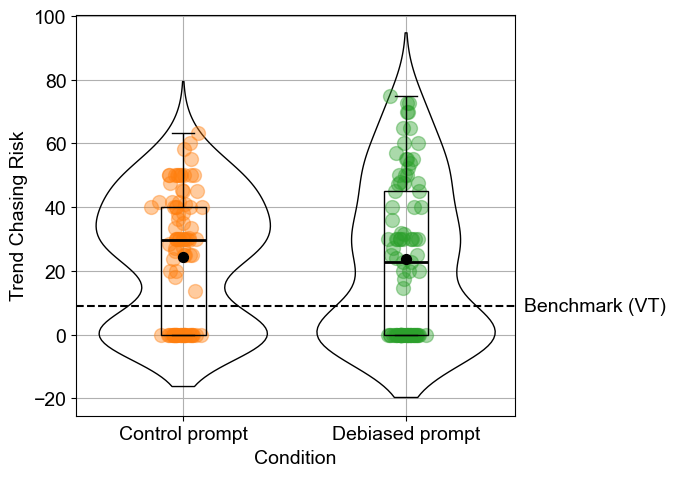

In [42]:
show_benchmark_violinplot(
    trends_data, 
    benchmark_trends, 
    'Benchmark (VT)', 
    'weight',
    'Trend Chasing Risk', #Top 3 trending equities portfolio share [%]
    'cond',
    'study2a_trendRisk'
)

                sum_sq     df         F    PR(>F)
label        33.167823    1.0  0.067007  0.796044
Residual  88108.017742  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1          group2     meandiff p-adj  lower  upper  reject
-------------------------------------------------------------------
Control prompt Debiased prompt  -0.8585 0.796 -7.4034 5.6864  False
-------------------------------------------------------------------
group: ('Control prompt',) got t: 7.338223391422966 p_value: 0.0 dfs: 89 benchmark: 9.0022
group: ('Debiased prompt',) got t: 5.723280702525749 p_value: 0.0 dfs: 89 benchmark: 9.0022


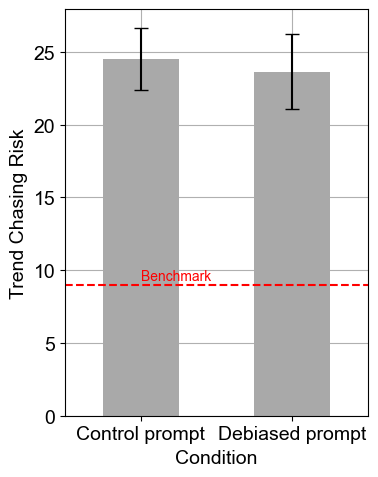

In [43]:
show_benchmark_errplot(
    trends_data, 
    benchmark_trends, 
    'Benchmark', 
    'weight',
    'Trend Chasing Risk', #Top 3 trending equities portfolio share [%]
    'cond')